<a href="https://colab.research.google.com/github/jiissung/ECON3916-Statistical-Machine-Learning/blob/main/Class%2016/Lab_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [29]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
# Format: 'indicator_code': 'human_readable_name'
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

# Download 7 years of data (2013–2019, pre-COVID) and average
# wb.data.DataFrame returns a DataFrame indexed by (economy, time) or (economy)
try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False,
        columns='series'
    )
    raw_data = raw_data.rename(columns=INDICATORS)
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")
    # Fallback: load pre-downloaded CSV
    # raw_data = pd.read_csv('data/fallback_wdi_topic16.csv', index_col=[0, 1])

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (1855, 35)
Download successful ✓


In [30]:
# ============================================================
# PART 1B: Build the Analysis Dataset
# ============================================================
# Average all indicators across the 2013-2019 period per country
# This gives us one observation per country — a cross-sectional dataset

# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    country_data = raw_data.groupby(level=0).mean()
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
# (Standard practice in cross-country empirics — removes selection bias from listwise deletion)
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

In [31]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================
# We split countries (not time periods) into train/test sets.
# This tests whether our model generalizes across countries —
# the realistic use case for an IMF forecaster.

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split (stratified not needed for regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso — do it manually here to inspect later)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 28
Predictor-to-observation ratio (train): p/n = 28/166 = 0.17

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [32]:
# ============================================================
# PART 1D: OLS Baseline — Demonstrating the Failure Mode
# ============================================================
# OLS will overfit when p/n is large. We predict this BEFORE looking at results.
# Prediction: high training R², but much lower (possibly negative) test R².

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")

OLS BASELINE RESULTS
Training R²:  0.600
Test R²:      -0.849

Training MSE: 2.640
Test MSE:     8.252

Gap (Train R² - Test R²): 1.449

Interpretation:
  OLS fits the training data 60% — but only explains
  0% of test variance. This is overfitting.


In [33]:
# Grid of lambda (alpha) values to try — log-spaced from 0.01 to 1000
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create a RidgeCV with 5-fold CV and the lambda_grid above
# Hint: RidgeCV(alphas=..., cv=5)
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)

# TODO: Fit ridge_cv on the scaled training data
ridge_cv.fit(X_train_scaled, y_train)

# Evaluate on test set
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}")
print(f"Test R²:                  {ridge_test_r2:.3f}")
print(f"Test MSE:                 {ridge_test_mse:.3f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 47.1487
Non-zero coefficients:    28 of 28
Test R²:                  -0.051
Test MSE:                 4.691

vs. OLS: Test R² = -0.849, Test MSE = 8.252


In [36]:
def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray, shape (n_train, p)
        Standardized training features
    y_train : np.ndarray, shape (n_train,)
        Training outcome (GDP growth)
    X_test : np.ndarray, shape (n_test, p)
        Standardized test features (same scaler as train)
    y_test : np.ndarray, shape (n_test,)
        Test outcome
    cv : int
        Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV
        Fitted LassoCV model with optimal alpha stored in .alpha_
    test_r2 : float
        R² on held-out test set
    test_mse : float
        Mean squared error on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    # (max_iter needs to be high for coordinate descent to converge)
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)  # ← your code here

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)
    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)

    return lasso_model, test_r2, test_mse


# Call the function
lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}")
print(f"Test R²:                  {lasso_test_r2:.3f}")
print(f"Test MSE:                 {lasso_test_mse:.3f}")
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.0656
Non-zero coefficients:    17 of 28
Test R²:                  -0.330
Test MSE:                 5.934

Selected predictors (non-zero Lasso coefficients):
  inflation_cpi                            coef = -1.0240
  population_growth                        coef = -0.7706
  natural_resource_rents_pct_gdp           coef = -0.6521
  health_expenditure_pct_gdp               coef = -0.4145
  infant_mortality_per1000                 coef = -0.3856
  atms_per100k                             coef = -0.3850
  unemployment_rate                        coef = -0.3716
  renewable_energy_pct                     coef = +0.3627
  urbanization_pct                         coef = -0.3546
  exchange_rate_official                   coef = +0.3112
  arable_land_pct                          coef = +0.1881
  tertiary_enrollment_gross                coef = -0.0797
  mobile_subscriptions_per100              coef = +0.0729
  private_credit_pct_gdp            

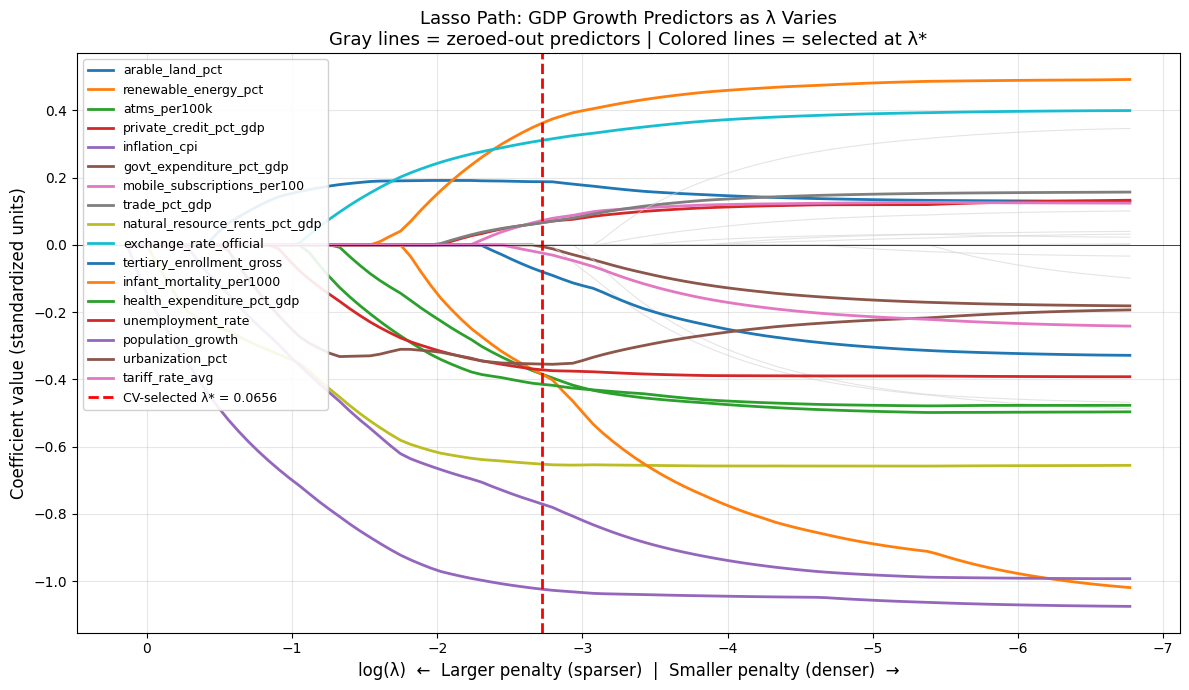

Lasso Path saved to lasso_path_gdp_growth.png


In [37]:
# lasso_path returns: (alphas, coefs, dual_gaps)
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,       # ratio of min to max alpha in the path
    n_alphas=100,   # number of points on the path
)
# coefs_path shape: (n_features, n_alphas)

# Mark our CV-selected lambda
optimal_alpha = lasso_cv_model.alpha_

# ── PLOT ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each predictor's coefficient path
# Only label the lines that are non-zero at optimal λ (to avoid clutter)
active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

# Mark the CV-selected lambda
ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

# Labels and formatting
ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()  # Large lambda on left → small lambda on right (path goes left to right)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lasso Path saved to lasso_path_gdp_growth.png")

In [38]:
comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train.shape[1],                        # OLS: all predictors non-zero
        X_train.shape[1],                        # Ridge: all predictors non-zero
        np.sum(lasso_cv_model.coef_ != 0)        # Lasso: only selected predictors
    ],
    'Training R²': [
        f'{r2_score(y_train, ols_model.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, ridge_cv.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, lasso_cv_model.predict(X_train_scaled)):.3f}'
    ],
    'Test R²': [
        f'{ols_test_r2:.3f}',
        f'{ridge_test_r2:.3f}',
        f'{lasso_test_r2:.3f}'
    ],
    'Test MSE': [
        f'{ols_test_mse:.3f}',
        f'{ridge_test_mse:.3f}',
        f'{lasso_test_mse:.3f}'
    ]
})

print(comparison.to_string(index=False))
print()
print("Key observations:")
print(f"  • OLS training R² >> test R²: evidence of overfitting (high variance)")
print(f"  • Ridge and Lasso reduce the train-test gap")
print(f"  • Lasso selects only {np.sum(lasso_cv_model.coef_ != 0)} of {X_train.shape[1]} predictors")
print(f"  • Interpretation: the other {X_train.shape[1] - np.sum(lasso_cv_model.coef_ != 0)} are predictively redundant,")
print(f"    not necessarily economically unimportant")

         Method      Lambda (α*)  Non-zero Predictors Training R² Test R² Test MSE
            OLS N/A (no penalty)                   28       0.600  -0.849    8.252
Ridge (RidgeCV)          47.1487                   28       0.557  -0.051    4.691
Lasso (LassoCV)           0.0656                   17       0.569  -0.330    5.934

Key observations:
  • OLS training R² >> test R²: evidence of overfitting (high variance)
  • Ridge and Lasso reduce the train-test gap
  • Lasso selects only 17 of 28 predictors
  • Interpretation: the other 11 are predictively redundant,
    not necessarily economically unimportant


My colleague is incorrect because Lasso sets coefficients to zero if the variable is redundant with other variables. For example, if one variable is highly correlated with another, Lasso may drop it becuase it is already captured. The variable still may be economically important for GDP growth, even if it was dropped by Lasso.

In this case, Ridge regression is better than Lasso. This is because this dataset contains many correlated variables. Additioanlly Lasso may drop relevant but correlated variables, especially in this type of dataset.

2026-04-02 00:17:39.011 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 00:17:39.014 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 00:17:39.293 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-02 00:17:39.294 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 00:17:39.300 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 00:17:39.303 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-02 00:17:39.309 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

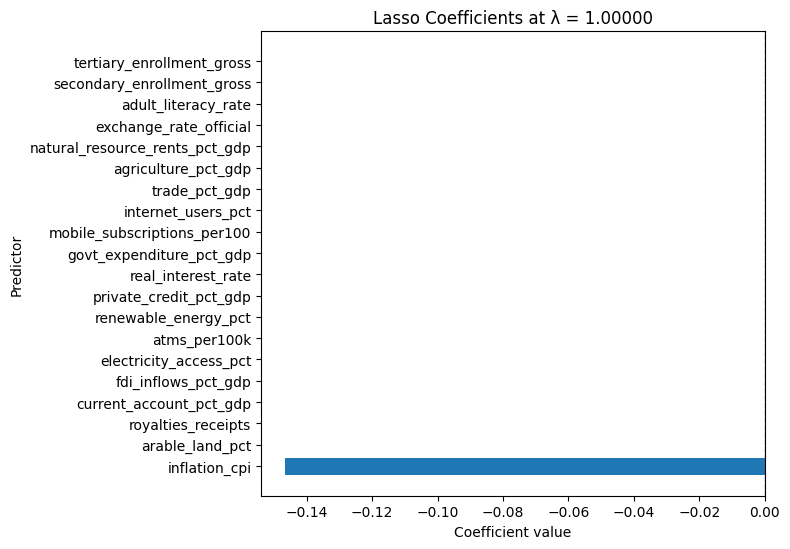

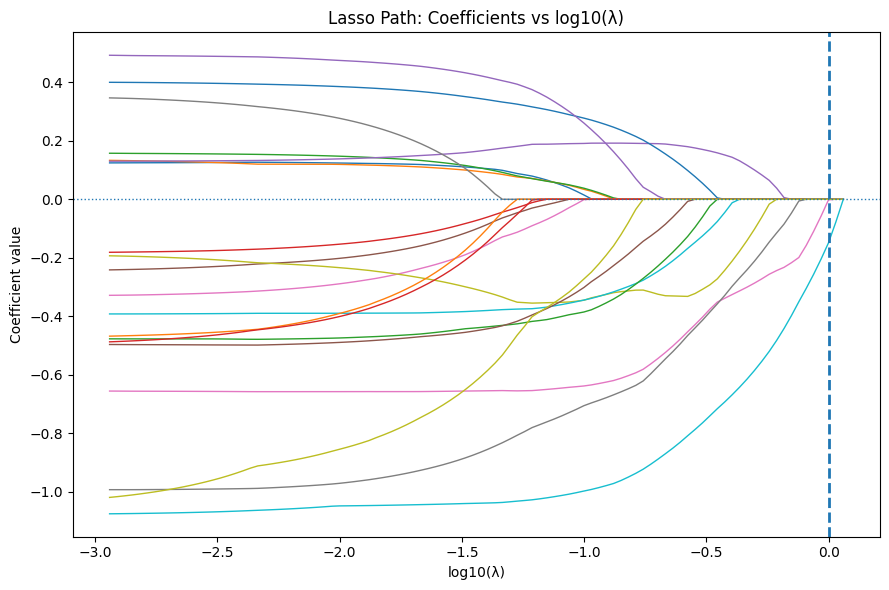

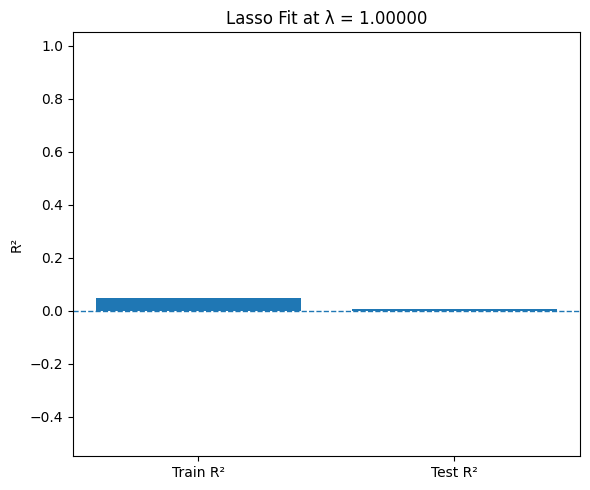

In [40]:
# app.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st

from sklearn.linear_model import Ridge, Lasso, lasso_path
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ============================================================
# STREAMLIT PAGE SETUP
# ============================================================
st.set_page_config(
    page_title="Regularization Dashboard: Ridge vs Lasso",
    layout="wide"
)

st.title("Econometric ML Dashboard: Ridge, Lasso, and the Lasso Path")
st.markdown(
    """
Interactive dashboard for exploring how regularization changes coefficient magnitude,
model fit, and overfitting behavior in a cross-country World Development Indicators dataset.
"""
)

# ============================================================
# IMPORTANT: DATA BLOCK
# ============================================================
# This app expects the following variables to exist with the SAME names used in your notebook:
#   country_data, OUTCOME_VAR, feature_names, X_train_scaled, X_test_scaled, y_train, y_test
#
# EASIEST WORKFLOW:
# 1) Copy your notebook's data-prep cells into this script ABOVE the dashboard section, OR
# 2) Save those objects to disk and load them here.
#
# The block below is only a safety check. It does not overwrite your real variables.
required_vars = [
    "country_data",
    "OUTCOME_VAR",
    "feature_names",
    "X_train_scaled",
    "X_test_scaled",
    "y_train",
    "y_test",
]

missing = [name for name in required_vars if name not in globals()]
if missing:
    st.error(
        "Missing required variables from your notebook:\n\n"
        + ", ".join(missing)
        + "\n\nPaste your existing data-prep code above this dashboard code "
          "so these variables are created before the app runs."
    )
    st.stop()

# Convert feature_names to a clean list in case it is a pandas Index
feature_names = list(feature_names)

# ============================================================
# SIDEBAR CONTROLS
# ============================================================
st.sidebar.header("Controls")

model_type = st.sidebar.radio(
    "Choose model for coefficient / R² panels",
    options=["Lasso", "Ridge"],
    index=0
)

default_lambda = 1.0
lambda_value = st.sidebar.slider(
    "Regularization strength λ (alpha)",
    min_value=-4.0,
    max_value=2.0,
    value=float(np.log10(default_lambda)),
    step=0.05,
    help="This slider is on a log10 scale. The actual lambda used in the model is 10^(slider value)."
)

alpha = 10 ** lambda_value

top_n = st.sidebar.slider(
    "Number of coefficients to display",
    min_value=10,
    max_value=min(len(feature_names), 40),
    value=min(20, len(feature_names)),
    step=1
)

show_all_paths = st.sidebar.checkbox(
    "Show all coefficient paths",
    value=False
)

# ============================================================
# MODEL FIT FUNCTION
# ============================================================
def fit_current_model(model_name, alpha, X_train_scaled, y_train, X_test_scaled, y_test):
    """
    Refit the selected model at the current lambda value.

    Streamlit reruns the full script whenever the user moves a widget such as st.slider().
    That means each slider move updates 'alpha', then this function is called again with
    the new alpha, which refits Ridge or Lasso at the newly selected lambda.
    """
    if model_name == "Lasso":
        model = Lasso(alpha=alpha, max_iter=10_000, random_state=42)
    else:
        model = Ridge(alpha=alpha, random_state=42)

    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": model.coef_
    }).sort_values("coefficient", key=np.abs, ascending=False)

    return model, coef_df, train_r2, test_r2


# ============================================================
# CACHE LASSO PATH
# ============================================================
@st.cache_data
def compute_lasso_path_cached(X_train_scaled, y_train):
    """
    Compute the full Lasso coefficient path once and cache it.

    We cache this because lasso_path() can be relatively expensive, and Streamlit reruns
    the script every time the slider changes. Without caching, dragging the lambda slider
    would recompute the entire path on every move, which would make the app feel slow.
    st.cache_data is intended for caching serializable data results like arrays/dataframes.
    """
    # scikit-learn returns alphas in descending order by default
    alphas, coefs, _ = lasso_path(X_train_scaled, y_train, max_iter=10_000)
    return alphas, coefs


# ============================================================
# FIT CURRENT MODEL AND GET PATH
# ============================================================
model, coef_df, train_r2, test_r2 = fit_current_model(
    model_type, alpha, X_train_scaled, y_train, X_test_scaled, y_test
)

lasso_alphas, lasso_coefs = compute_lasso_path_cached(X_train_scaled, y_train)

# Find nearest precomputed lasso-path alpha to the current slider alpha
nearest_idx = int(np.argmin(np.abs(lasso_alphas - alpha)))
nearest_path_alpha = lasso_alphas[nearest_idx]

# ============================================================
# TOP METRICS
# ============================================================
c1, c2, c3, c4 = st.columns(4)
c1.metric("Selected model", model_type)
c2.metric("Current λ (alpha)", f"{alpha:.5f}")
c3.metric("Train R²", f"{train_r2:.3f}")
c4.metric("Test R²", f"{test_r2:.3f}")

# Optional summary table
with st.expander("Dataset summary"):
    st.write(f"Countries: {len(country_data)}")
    st.write(f"Outcome variable: {OUTCOME_VAR}")
    st.write(f"Number of predictors: {len(feature_names)}")
    st.dataframe(country_data.head())

# ============================================================
# PANEL LAYOUT
# ============================================================
col1, col2, col3 = st.columns([1.15, 1.25, 0.9])

# ------------------------------------------------------------
# PANEL 1: COEFFICIENT BAR CHART
# ------------------------------------------------------------
with col1:
    st.subheader("1) Coefficient Bar Chart")

    coef_plot_df = coef_df.head(top_n).sort_values("coefficient")

    fig1, ax1 = plt.subplots(figsize=(8, max(5, 0.28 * len(coef_plot_df))))
    ax1.barh(coef_plot_df["feature"], coef_plot_df["coefficient"])
    ax1.axvline(0, linestyle="--", linewidth=1)
    ax1.set_title(f"{model_type} Coefficients at λ = {alpha:.5f}")
    ax1.set_xlabel("Coefficient value")
    ax1.set_ylabel("Predictor")
    plt.tight_layout()

    st.pyplot(fig1)

    st.caption(
        "As λ increases, regularization gets stronger. Ridge shrinks coefficients smoothly; "
        "Lasso can shrink some coefficients all the way to exactly zero."
    )

# ------------------------------------------------------------
# PANEL 2: LASSO PATH PLOT
# ------------------------------------------------------------
with col2:
    st.subheader("2) Lasso Path")

    fig2, ax2 = plt.subplots(figsize=(9, 6))

    x_vals = np.log10(lasso_alphas)

    if show_all_paths:
        for i in range(lasso_coefs.shape[0]):
            ax2.plot(x_vals, lasso_coefs[i], linewidth=1)
    else:
        # Show only the most important paths by max absolute coefficient along the path
        path_strength = np.max(np.abs(lasso_coefs), axis=1)
        top_idx = np.argsort(path_strength)[-min(top_n, len(feature_names)):]
        for i in top_idx:
            ax2.plot(x_vals, lasso_coefs[i], linewidth=1, label=feature_names[i])

        # Keep legend manageable
        if len(top_idx) <= 15:
            ax2.legend(loc="best", fontsize=8)

    # This vertical line updates because the slider changes 'alpha', Streamlit reruns,
    # and then axvline() is redrawn at the new log10(alpha) position.
    ax2.axvline(
        np.log10(alpha),
        linestyle="--",
        linewidth=2,
        label=f"Selected λ = {alpha:.5f}"
    )

    ax2.axhline(0, linestyle=":", linewidth=1)
    ax2.set_title("Lasso Path: Coefficients vs log10(λ)")
    ax2.set_xlabel("log10(λ)")
    ax2.set_ylabel("Coefficient value")
    plt.tight_layout()

    st.pyplot(fig2)

    st.caption(
        f"The dashed vertical line marks your current slider choice. "
        f"The nearest precomputed path value is λ ≈ {nearest_path_alpha:.5f}."
    )

# ------------------------------------------------------------
# PANEL 3: TRAIN / TEST R² COMPARISON
# ------------------------------------------------------------
with col3:
    st.subheader("3) Train vs Test R²")

    fig3, ax3 = plt.subplots(figsize=(6, 5))
    ax3.bar(["Train R²", "Test R²"], [train_r2, test_r2])
    ax3.axhline(0, linestyle="--", linewidth=1)
    ax3.set_ylim(
        min(-0.5, train_r2, test_r2) - 0.05,
        max(1.0, train_r2, test_r2) + 0.05
    )
    ax3.set_title(f"{model_type} Fit at λ = {alpha:.5f}")
    ax3.set_ylabel("R²")
    plt.tight_layout()

    st.pyplot(fig3)

    gap = train_r2 - test_r2
    st.write(f"**Generalization gap:** {gap:.3f}")

# ============================================================
# OPTIONAL TABLE OF CURRENT COEFFICIENTS
# ============================================================
with st.expander("Current coefficient table"):
    st.dataframe(
        coef_df.assign(abs_coefficient=np.abs(coef_df["coefficient"])),
        use_container_width=True
    )

# ============================================================
# INTERPRETATION GUIDE
# ============================================================
st.markdown("---")
st.subheader("How to interpret the dashboard")

st.markdown(
    """
- **Very high λ:** the penalty is strong, so coefficients are pushed close to zero.
  For **Lasso**, many coefficients may become exactly zero; for **Ridge**, coefficients usually become very small but not exactly zero. This is a high-bias setting, so both train and test R² can fall.

- **Very low λ:** the penalty becomes weak, so the model approaches **OLS-like behavior**.
  Coefficients can become large and unstable, especially with correlated predictors and a moderately high predictor-to-sample ratio. In that case, train R² often rises while test R² may deteriorate because the model starts fitting noise.

- **CV-optimal λ:** this is usually the best compromise between underfitting and overfitting.
  At that point, the model keeps enough signal to predict well out of sample while still controlling variance.

- **Why train and test R² diverge at extreme λ values in opposite directions:**
  At **very low λ**, the model is too flexible, so **train R² goes up** but **test R² can go down** from overfitting.
  At **very high λ**, the model is too constrained, so **both** train and test fit can weaken, but train R² often falls first because the model can no longer capture enough structure even in the training sample.
"""
)

st.markdown(
    """
**Tip for your lab write-up:** if your WDI predictors are strongly correlated proxies for development
(such as internet use, electricity access, urbanization, and life expectancy), then coefficient movement
across λ reflects not just “importance” but also how the regularizer reallocates shared signal across a
correlated predictor set.
"""
)

# ============================================================
# FOOTER
# ============================================================
st.markdown("---")
st.caption(
    "Built with Streamlit, scikit-learn, matplotlib, pandas, and numpy."
)